# RS2 Final: Custom Model dan Custom Training

## 🏥 SmartQueue AI — Prediksi Waktu Tunggu Pasien Rumah Sakit

Notebook ini mendemonstrasikan pengembangan model **Deep Learning** untuk memprediksi waktu tunggu pasien di rumah sakit menggunakan berbagai komponen custom TensorFlow/Keras.

### 🧩 Komponen Custom yang Digunakan:

| Komponen | Class | Deskripsi |
|----------|-------|-----------|
| **Custom Layer** | `ResidualDenseBlock` | Dense layer dengan skip connection + BatchNormalization |
| **Custom Loss** | `WeightedHuberLoss` | Huber Loss asimetris — penalti lebih berat untuk under-prediction |
| **Custom Callback** | `DetailedTrainingLogger` | Mencatat metrik training per epoch ke file JSON |
| **Custom Training Loop** | `tf.GradientTape` | Training manual untuk kontrol penuh proses pelatihan |
| **TensorBoard** | `TensorBoard Callback` | Logging metrik untuk visualisasi interaktif |

### 📋 Arsitektur:
- **Functional API** dengan Residual Dense Blocks
- Dropout regularization untuk mencegah overfitting
- BatchNormalization untuk stabilisasi training
- ReduceLROnPlateau untuk adaptive learning rate

In [1]:
import os
import datetime
import json
import warnings
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input, LSTM
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, Callback, TensorBoard

warnings.filterwarnings("ignore")
np.random.seed(42)
tf.random.set_seed(42)

# Menggunakan pengecekan dinamis agar aman di .py maupun .ipynb
if "__file__" in globals():
    BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
else:
    BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))

DATASET_PATH = os.path.join(BASE_DIR, "datasets", "dataset_RS2_final.csv")
MODEL_DIR = os.path.join(BASE_DIR, "deployment", "model")
os.makedirs(MODEL_DIR, exist_ok=True)


/Users/khairul/Library/Mobile Documents/com~apple~CloudDocs/KULIAH/KEGIATAN/CODING CAMP/CAPSTONE PROJECT/smartqueue_project/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


### 1. Load Data

In [2]:
print("Loading dataset...")
df = pd.read_csv(DATASET_PATH)

Loading dataset...


### 2. Preprocessing

In [3]:
print("Preprocessing dataset...")
df['tanggal'] = pd.to_datetime(df['tanggal'])
df['waktu_kedatangan'] = pd.to_datetime(df['waktu_kedatangan'])
df['waktu_registrasi'] = pd.to_datetime(df['waktu_registrasi'])
df['waktu_mulai_layanan'] = pd.to_datetime(df['waktu_mulai_layanan'])
df['waktu_selesai_layanan'] = pd.to_datetime(df['waktu_selesai_layanan'])

Preprocessing dataset...


### Sort by chronological order for TimeSeriesSplit

In [4]:
df = df.sort_values(by=['tanggal', 'waktu_kedatangan']).reset_index(drop=True)

df['day_of_week'] = df['tanggal'].dt.dayofweek
df['month'] = df['tanggal'].dt.month
df['week_of_year'] = df['tanggal'].dt.isocalendar().week.astype(int)

df['hour_sin'] = np.sin(2 * np.pi * df['jam_kedatangan'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['jam_kedatangan'] / 24)

### Fix is_peak definition as per app.py

In [5]:
df['is_peak'] = ((df['jam_kedatangan'] >= 8) & (df['jam_kedatangan'] <= 11)).astype(int)

drop_columns = [
    'tanggal', 'waktu_kedatangan', 'waktu_registrasi', 'waktu_mulai_layanan',
    'waktu_selesai_layanan', 'jenis_kelamin', 'asuransi', 'status_pasien',
    'prioritas', 'nama_poli', 'hari', 'calc_wait', 'biaya', 'kepuasan_pasien',
    'durasi_layanan'
]

df_clean = df.drop(columns=drop_columns)

X = df_clean.drop(columns=['waktu_tunggu'])
y = df_clean['waktu_tunggu']

feature_columns = X.columns.tolist()
joblib.dump(feature_columns, os.path.join(MODEL_DIR, "feature_columns.pkl"))
print("Feature columns:", feature_columns)

Feature columns: ['umur', 'jumlah_antrian', 'jam_kedatangan', 'is_peak', 'asuransi_enc', 'prioritas_enc', 'status_pasien_enc', 'nama_poli_enc', 'day_of_week', 'month', 'week_of_year', 'hour_sin', 'hour_cos']


### 3. Data Split (TimeSeriesSplit) - NO DATA LEAKAGE

In [6]:
print("\nSplitting dataset...")
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)


Splitting dataset...


### We use the final split for our train/test sets

In [7]:
for train_index, test_index in tscv.split(X):
    X_train_raw, X_test_raw = X.iloc[train_index], X.iloc[test_index]
    y_train_raw, y_test_raw = y.iloc[train_index], y.iloc[test_index]

print("X_train shape:", X_train_raw.shape)
print("X_test shape:", X_test_raw.shape)

X_train shape: (16667, 13)
X_test shape: (3333, 13)


### 4. Scaling (FIT ONLY ON TRAIN DATA)

In [8]:
print("\nScaling data...")
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

target_scaler = MinMaxScaler()
y_train = target_scaler.fit_transform(y_train_raw.values.reshape(-1, 1)).flatten()
y_test = target_scaler.transform(y_test_raw.values.reshape(-1, 1)).flatten()

joblib.dump(scaler, os.path.join(MODEL_DIR, "feature_scaler.save"))
joblib.dump(target_scaler, os.path.join(MODEL_DIR, "target_scaler.save"))
print("Scalers saved.")


Scaling data...
Scalers saved.


### 5. Model Definition

#### Custom Loss Function: `WeightedHuberLoss`
Loss function custom yang menggabungkan keunggulan Huber Loss (robust terhadap outlier) dengan **penalti asimetris**:
- **Under-prediction** (prediksi lebih singkat dari kenyataan) mendapat penalti **1.5x** lebih berat
- Alasan: Dalam konteks rumah sakit, lebih baik pasien diberitahu waktu tunggu sedikit lebih lama daripada terlalu singkat

#### Custom Layer: `ResidualDenseBlock`
Layer custom yang mengimplementasikan **skip connection** (residual learning):
- Input → Dense → BatchNorm → Dense → BatchNorm → **+ Input** → Output
- Skip connection membantu mengatasi vanishing gradient dan memungkinkan model lebih dalam

#### Arsitektur Model (Functional API):
```
Input(13) → Dense(512) → BN → Dropout(0.3)
         → ResidualDenseBlock(256) → Dropout(0.2)
         → ResidualDenseBlock(128) → Dropout(0.2)
         → Dense(64) → BN → Dense(32) → Dense(1)
```

In [9]:
print("\nBuilding Deep Learning Model...")

@tf.keras.utils.register_keras_serializable(package="Custom")
class WeightedHuberLoss(tf.keras.losses.Loss):
    def __init__(self, delta=1.0, under_weight=1.5, name="weighted_huber_loss", **kwargs):
        super().__init__(name=name, **kwargs)
        self.delta = delta
        self.under_weight = under_weight

    def call(self, y_true, y_pred):
        y_pred = tf.convert_to_tensor(y_pred)
        y_true = tf.cast(y_true, y_pred.dtype)
        y_true = tf.reshape(y_true, tf.shape(y_pred))
        error = y_true - y_pred
        abs_error = tf.abs(error)
        quadratic = tf.minimum(abs_error, self.delta)
        linear = abs_error - quadratic
        base_loss = 0.5 * quadratic**2 + self.delta * linear
        weight = tf.where(error > 0, self.under_weight, 1.0)
        return tf.reduce_mean(weight * base_loss)

    def get_config(self):
        config = super().get_config()
        config.update({"delta": self.delta, "under_weight": self.under_weight})
        return config

@tf.keras.utils.register_keras_serializable(package="Custom")
class ResidualDenseBlock(tf.keras.layers.Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.dense1 = tf.keras.layers.Dense(units, activation="relu")
        self.bn1 = tf.keras.layers.BatchNormalization()
        self.dense2 = tf.keras.layers.Dense(units, activation="relu")
        self.bn2 = tf.keras.layers.BatchNormalization()

    def build(self, input_shape):
        self.dense1.build(input_shape)
        hidden_shape = self.dense1.compute_output_shape(input_shape)
        self.bn1.build(hidden_shape)
        self.dense2.build(hidden_shape)
        self.bn2.build(hidden_shape)
        super().build(input_shape)

    def call(self, inputs, training=False):
        x = self.dense1(inputs)
        x = self.bn1(x, training=training)
        residual = x
        x = self.dense2(x)
        x = self.bn2(x, training=training)
        return x + residual

    def get_config(self):
        config = super().get_config()
        config.update({"units": self.units})
        return config

inputs = Input(shape=(X_train.shape[1],))
x = Dense(512, activation='relu')(inputs)
x = BatchNormalization()(x)
x = Dropout(0.1)(x)

x = ResidualDenseBlock(256)(x)
x = Dropout(0.1)(x)
x = ResidualDenseBlock(128)(x)
x = Dropout(0.1)(x)
x = Dense(64, activation='relu')(x)
x = BatchNormalization()(x)
x = Dense(32, activation='relu')(x)
outputs = Dense(1)(x)

model = Model(inputs=inputs, outputs=outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=WeightedHuberLoss(delta=1.0, under_weight=1.1),
    metrics=['mae']
)


Building Deep Learning Model...


### 📐 Model Architecture Visualization

Visualisasi arsitektur model untuk memahami flow data melalui setiap layer. Model menggunakan **Functional API** dengan dua `ResidualDenseBlock` yang memungkinkan gradient flow yang lebih baik melalui skip connections.

In [10]:
# === MODEL ARCHITECTURE SUMMARY ===
print("=" * 60)
print("MODEL ARCHITECTURE SUMMARY")
print("=" * 60)
model.summary()

# Visualisasi diagram arsitektur model
try:
    arch_path = os.path.join(MODEL_DIR, 'model_architecture.png')
    tf.keras.utils.plot_model(
        model,
        to_file=arch_path,
        show_shapes=True,
        show_layer_names=True,
        show_layer_activations=True,
        dpi=150
    )
    from IPython.display import Image, display
    display(Image(filename=arch_path))
    print(f"\n✅ Diagram arsitektur tersimpan di {arch_path}")
except Exception as e:
    print(f"⚠️ Tidak dapat membuat diagram arsitektur: {e}")
    print("Install graphviz dan pydot jika ingin melihat diagram:")
    print("  pip install pydot graphviz")

MODEL ARCHITECTURE SUMMARY


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 13)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_dense_block            │ (None, 256)            │       199,168 │
│ (ResidualDenseBlock)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_dense_block_1          │ (None, 128)            │        50,432 │
│ (ResidualDenseBlock)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,441 (1.03 MB)

 Trainable params: 266,753 (1.02 MB)

 Non-trainable params: 2,688 (10.50 KB)

You must install pydot (`pip install pydot`) for `plot_model` to work.
⚠️ Tidak dapat membuat diagram arsitektur: [Errno 2] No such file or directory: '/Users/khairul/Library/Mobile Documents/com~apple~CloudDocs/KULIAH/KEGIATAN/CODING CAMP/CAPSTONE PROJECT/smartqueue_project/deployment/model/model_architecture.png'
Install graphviz dan pydot jika ingin melihat diagram:
  pip install pydot graphviz


### Callbacks

Callback yang digunakan dalam training:

1. **EarlyStopping** — Menghentikan training jika `val_loss` tidak membaik selama 15 epoch, dan mengembalikan weights terbaik
2. **ModelCheckpoint** — Menyimpan model terbaik ke `best_model.keras` berdasarkan `val_loss` terendah
3. **ReduceLROnPlateau** — Menurunkan learning rate 50% jika `val_loss` tidak membaik selama 5 epoch
4. **DetailedTrainingLogger** *(Custom Callback)* — Mencatat semua metrik per epoch ke file JSON untuk analisis dan audit trail
5. **TensorBoard** — Logging metrik dan histogram weights untuk visualisasi interaktif

In [11]:
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
checkpoint = ModelCheckpoint(os.path.join(MODEL_DIR, "best_model.keras"), monitor='val_loss', save_best_only=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

class DetailedTrainingLogger(Callback):
    def __init__(self, log_path):
        super().__init__()
        self.log_path = log_path
        self.history = {"epochs": []}

    def on_epoch_end(self, epoch, logs=None):
        epoch_data = {
            "epoch": epoch + 1,
            "loss": float(logs.get("loss", 0)),
            "mae": float(logs.get("mae", 0)),
            "val_loss": float(logs.get("val_loss", 0)),
            "val_mae": float(logs.get("val_mae", 0)),
            "lr": float(tf.keras.backend.get_value(self.model.optimizer.learning_rate)),
        }
        self.history["epochs"].append(epoch_data)

    def on_train_end(self, logs=None):
        with open(self.log_path, "w") as f:
            json.dump(self.history, f, indent=2)
        print(f"\nTraining log saved to {self.log_path}")

training_logger = DetailedTrainingLogger(os.path.join(MODEL_DIR, "training_log.json"))

LOG_DIR = os.path.join(BASE_DIR, "logs", "fit", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_cb = TensorBoard(log_dir=LOG_DIR, histogram_freq=1)

### Training

Training model menggunakan `model.fit()` dengan konfigurasi:
- **Epochs:** 150 (maksimum, dengan EarlyStopping)
- **Batch Size:** 64
- **Validation Split:** 20% dari data training
- **Loss Function:** `WeightedHuberLoss` (custom asymmetric Huber)
- **Optimizer:** Adam (lr=0.0005)

In [12]:
print("\nTraining DL Model...")
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=64,
    callbacks=[early_stopping, checkpoint, reduce_lr, training_logger, tensorboard_cb],
    verbose=1
)


Training DL Model...
Epoch 1/150
209/209 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.1587 - mae: 0.3830 - val_loss: 0.0157 - val_mae: 0.1456 - learning_rate: 0.0010
Epoch 2/150
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0105 - mae: 0.1102 - val_loss: 0.0045 - val_mae: 0.0749 - learning_rate: 0.0010
Epoch 3/150
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0062 - mae: 0.0851 - val_loss: 0.0029 - val_mae: 0.0583 - learning_rate: 0.0010
Epoch 4/150
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0044 - mae: 0.0723 - val_loss: 0.0023 - val_mae: 0.0528 - learning_rate: 0.0010
Epoch 5/150
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0036 - mae: 0.0651 - val_loss: 0.0022 - val_mae: 0.0501 - learning_rate: 0.0010
Epoch 6/150
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0031 - mae: 0.0609 - val_loss: 0.0019 - val_mae: 0.0475 - learning_rate: 0.0010
Epoch 7/150
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0026 - mae: 0.0563 - val_loss: 0.0015 - val_mae: 0.0412 -

### 📊 Training History Visualization

Visualisasi proses training menunjukkan bagaimana model belajar dari waktu ke waktu:
- **Loss Curve** — Penurunan loss menunjukkan model semakin baik meminimalkan error
- **MAE Curve** — Penurunan MAE menunjukkan prediksi semakin akurat
- **Learning Rate** — Bagaimana `ReduceLROnPlateau` menurunkan learning rate saat model plateau

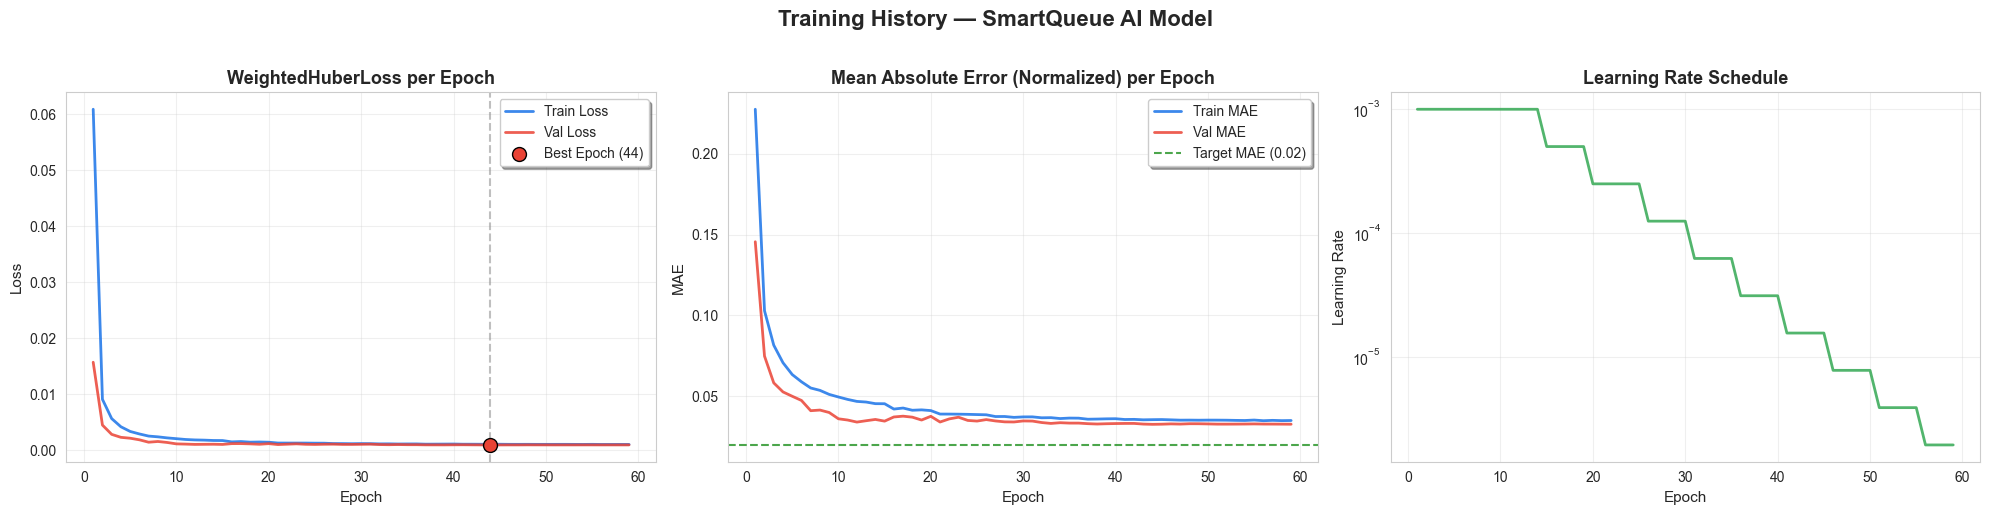


TRAINING SUMMARY
Total Epochs Trained: 59
Best Epoch: 44
Best Val Loss: 0.000969
Best Val MAE (normalized): 0.032736
Final Learning Rate: 1.95e-06


In [13]:
# === TRAINING HISTORY VISUALIZATION ===
sns.set_style('whitegrid')

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Training History — SmartQueue AI Model', fontsize=16, fontweight='bold', y=1.02)

# Color palette
c_train = '#1a73e8'
c_val = '#ea4335'
c_lr = '#34a853'

epochs_range = range(1, len(history.history['loss']) + 1)

# --- Plot 1: Loss ---
axes[0].plot(epochs_range, history.history['loss'], color=c_train, linewidth=2, label='Train Loss', alpha=0.85)
axes[0].plot(epochs_range, history.history['val_loss'], color=c_val, linewidth=2, label='Val Loss', alpha=0.85)
axes[0].set_title('WeightedHuberLoss per Epoch', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss', fontsize=11)

# Mark best epoch
best_epoch_idx = history.history['val_loss'].index(min(history.history['val_loss']))
axes[0].axvline(x=best_epoch_idx + 1, color='gray', linestyle='--', alpha=0.5)
axes[0].scatter([best_epoch_idx + 1], [history.history['val_loss'][best_epoch_idx]],
                color=c_val, s=100, zorder=5, edgecolors='black', label=f'Best Epoch ({best_epoch_idx + 1})')
axes[0].legend(fontsize=10, frameon=True, fancybox=True, shadow=True)
axes[0].grid(True, alpha=0.3)

# --- Plot 2: MAE ---
axes[1].plot(epochs_range, history.history['mae'], color=c_train, linewidth=2, label='Train MAE', alpha=0.85)
axes[1].plot(epochs_range, history.history['val_mae'], color=c_val, linewidth=2, label='Val MAE', alpha=0.85)
axes[1].axhline(y=0.02, color='green', linestyle='--', alpha=0.7, linewidth=1.5, label='Target MAE (0.02)')
axes[1].set_title('Mean Absolute Error (Normalized) per Epoch', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('MAE', fontsize=11)
axes[1].legend(fontsize=10, frameon=True, fancybox=True, shadow=True)
axes[1].grid(True, alpha=0.3)

# --- Plot 3: Learning Rate ---
lr_history = [e['lr'] for e in training_logger.history['epochs']]
axes[2].plot(range(1, len(lr_history) + 1), lr_history, color=c_lr, linewidth=2, alpha=0.85)
axes[2].set_title('Learning Rate Schedule', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Epoch', fontsize=11)
axes[2].set_ylabel('Learning Rate', fontsize=11)
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'training_history.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print summary
print(f"\n{'='*60}")
print(f"TRAINING SUMMARY")
print(f"{'='*60}")
print(f"Total Epochs Trained: {len(history.history['loss'])}")
print(f"Best Epoch: {best_epoch_idx + 1}")
print(f"Best Val Loss: {min(history.history['val_loss']):.6f}")
print(f"Best Val MAE (normalized): {min(history.history['val_mae']):.6f}")
print(f"Final Learning Rate: {lr_history[-1]:.2e}")
print(f"{'='*60}")

### 📊 TensorBoard

TensorBoard menyediakan visualisasi interaktif yang lebih detail termasuk:
- **Scalars** — Loss dan MAE per epoch (train + validation)
- **Histograms** — Distribusi weights dan biases setiap layer
- **Graphs** — Computation graph model

> **Catatan:** Jika widget TensorBoard tidak muncul inline, jalankan di terminal:
> ```
> tensorboard --logdir logs/fit
> ```

In [14]:
%load_ext tensorboard
%tensorboard --logdir ../logs/fit

### 5b. Custom Training Loop (`tf.GradientTape`)

Demonstrasi training menggunakan `tf.GradientTape` untuk **kontrol penuh** terhadap proses pelatihan. Berbeda dengan `model.fit()`, GradientTape memungkinkan:
- Kontrol manual atas forward pass dan backward pass
- Custom gradient computation dan manipulation
- Fleksibilitas untuk arsitektur training yang kompleks (GAN, multi-task learning, dll.)

> **Note:** Model ini dilatih terpisah sebagai demonstrasi. Model utama yang digunakan untuk evaluasi dan deployment tetap yang dilatih via `model.fit()`.


=== Custom Training Loop with tf.GradientTape ===
Training for 15 epochs with GradientTape...



2026-05-21 12:56:48.622502: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-21 12:56:48.999668: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  Epoch  1/15 — loss: 0.0393, mae: 0.1889, val_loss: 0.0120, val_mae: 0.1222


2026-05-21 12:57:07.340205: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  Epoch  2/15 — loss: 0.0067, mae: 0.0884, val_loss: 0.0031, val_mae: 0.0598
  Epoch  3/15 — loss: 0.0042, mae: 0.0705, val_loss: 0.0020, val_mae: 0.0489


2026-05-21 12:57:44.788608: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  Epoch  4/15 — loss: 0.0032, mae: 0.0616, val_loss: 0.0019, val_mae: 0.0472
  Epoch  5/15 — loss: 0.0027, mae: 0.0566, val_loss: 0.0016, val_mae: 0.0439
  Epoch  6/15 — loss: 0.0024, mae: 0.0532, val_loss: 0.0017, val_mae: 0.0467
  Epoch  7/15 — loss: 0.0021, mae: 0.0504, val_loss: 0.0014, val_mae: 0.0414


2026-05-21 12:58:53.409185: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  Epoch  8/15 — loss: 0.0019, mae: 0.0480, val_loss: 0.0013, val_mae: 0.0392
  Epoch  9/15 — loss: 0.0020, mae: 0.0483, val_loss: 0.0012, val_mae: 0.0371
  Epoch 10/15 — loss: 0.0018, mae: 0.0455, val_loss: 0.0012, val_mae: 0.0372
  Epoch 11/15 — loss: 0.0017, mae: 0.0451, val_loss: 0.0010, val_mae: 0.0341
  Epoch 12/15 — loss: 0.0016, mae: 0.0437, val_loss: 0.0012, val_mae: 0.0386
  Epoch 13/15 — loss: 0.0016, mae: 0.0433, val_loss: 0.0012, val_mae: 0.0370
  Epoch 14/15 — loss: 0.0015, mae: 0.0425, val_loss: 0.0010, val_mae: 0.0342
  Epoch 15/15 — loss: 0.0015, mae: 0.0422, val_loss: 0.0012, val_mae: 0.0371

✅ GradientTape custom training loop selesai.


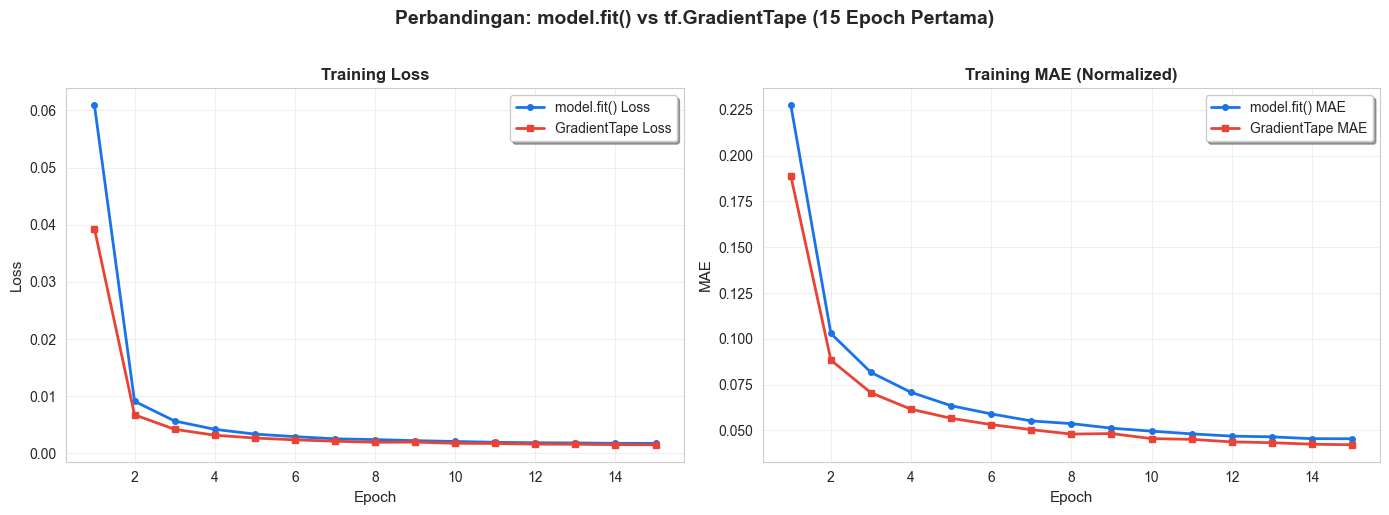


Kedua metode menggunakan arsitektur dan loss function yang sama.
model.fit() lebih cepat karena optimisasi internal Keras,
sedangkan GradientTape memberikan kontrol penuh untuk kasus advanced.


In [15]:
# === CUSTOM TRAINING LOOP DENGAN tf.GradientTape ===
print("\n=== Custom Training Loop with tf.GradientTape ===")

# Build model baru dengan arsitektur yang sama untuk demo GradientTape
gt_inputs = Input(shape=(X_train.shape[1],))
gt_x = Dense(512, activation='relu')(gt_inputs)
gt_x = BatchNormalization()(gt_x)
gt_x = Dropout(0.1)(gt_x)
gt_x = ResidualDenseBlock(256)(gt_x)
gt_x = Dropout(0.1)(gt_x)
gt_x = ResidualDenseBlock(128)(gt_x)
gt_x = Dropout(0.1)(gt_x)
gt_x = Dense(64, activation='relu')(gt_x)
gt_x = BatchNormalization()(gt_x)
gt_x = Dense(32, activation='relu')(gt_x)
gt_outputs = Dense(1)(gt_x)
gt_model = Model(inputs=gt_inputs, outputs=gt_outputs)

gt_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
gt_loss_fn = WeightedHuberLoss(delta=1.0, under_weight=1.1)
gt_mae_metric = tf.keras.metrics.MeanAbsoluteError()

train_dataset = tf.data.Dataset.from_tensor_slices(
    (X_train.astype("float32"), y_train.astype("float32"))
).shuffle(1024).batch(64)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (X_test.astype("float32"), y_test.astype("float32"))
).batch(64)

GT_EPOCHS = 15
print(f"Training for {GT_EPOCHS} epochs with GradientTape...\n")

# === Record metrics for visualization ===
gt_train_losses = []
gt_train_maes = []
gt_val_losses = []
gt_val_maes = []

for epoch in range(GT_EPOCHS):
    # === Training Step ===
    epoch_losses = []
    gt_mae_metric.reset_state()
    for x_batch, y_batch in train_dataset:
        with tf.GradientTape() as tape:
            predictions = gt_model(x_batch, training=True)
            loss = gt_loss_fn(y_batch, tf.squeeze(predictions))
        gradients = tape.gradient(loss, gt_model.trainable_variables)
        gt_optimizer.apply_gradients(zip(gradients, gt_model.trainable_variables))
        epoch_losses.append(float(loss))
        gt_mae_metric.update_state(y_batch, tf.squeeze(predictions))

    train_loss = sum(epoch_losses) / len(epoch_losses)
    train_mae = float(gt_mae_metric.result().numpy())

    # === Validation Step ===
    val_losses_batch = []
    gt_mae_metric.reset_state()
    for x_batch, y_batch in val_dataset:
        val_preds = gt_model(x_batch, training=False)
        v_loss = gt_loss_fn(y_batch, tf.squeeze(val_preds))
        val_losses_batch.append(float(v_loss))
        gt_mae_metric.update_state(y_batch, tf.squeeze(val_preds))

    val_loss = sum(val_losses_batch) / len(val_losses_batch)
    val_mae = float(gt_mae_metric.result().numpy())

    # Record for plotting
    gt_train_losses.append(train_loss)
    gt_train_maes.append(train_mae)
    gt_val_losses.append(val_loss)
    gt_val_maes.append(val_mae)

    print(f"  Epoch {epoch+1:2d}/{GT_EPOCHS} — "
          f"loss: {train_loss:.4f}, mae: {train_mae:.4f}, "
          f"val_loss: {val_loss:.4f}, val_mae: {val_mae:.4f}")

print("\n✅ GradientTape custom training loop selesai.")

# === VISUALIZATION: model.fit() vs GradientTape Comparison ===
sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Perbandingan: model.fit() vs tf.GradientTape (15 Epoch Pertama)',
             fontsize=14, fontweight='bold', y=1.02)

gt_range = range(1, GT_EPOCHS + 1)
fit_loss_subset = history.history['loss'][:GT_EPOCHS]
fit_mae_subset = history.history['mae'][:GT_EPOCHS]

# Loss comparison
axes[0].plot(gt_range, fit_loss_subset, color='#1a73e8', linewidth=2,
             label='model.fit() Loss', marker='o', markersize=4)
axes[0].plot(gt_range, gt_train_losses, color='#ea4335', linewidth=2,
             label='GradientTape Loss', marker='s', markersize=4)
axes[0].set_title('Training Loss', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss', fontsize=11)
axes[0].legend(fontsize=10, frameon=True, fancybox=True, shadow=True)
axes[0].grid(True, alpha=0.3)

# MAE comparison
axes[1].plot(gt_range, fit_mae_subset, color='#1a73e8', linewidth=2,
             label='model.fit() MAE', marker='o', markersize=4)
axes[1].plot(gt_range, gt_train_maes, color='#ea4335', linewidth=2,
             label='GradientTape MAE', marker='s', markersize=4)
axes[1].set_title('Training MAE (Normalized)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('MAE', fontsize=11)
axes[1].legend(fontsize=10, frameon=True, fancybox=True, shadow=True)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'gradienttape_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nKedua metode menggunakan arsitektur dan loss function yang sama.")
print("model.fit() lebih cepat karena optimisasi internal Keras,")
print("sedangkan GradientTape memberikan kontrol penuh untuk kasus advanced.")

### Load Best Model & Evaluasi

Model terbaik (berdasarkan `val_loss` terendah) dimuat dari `best_model.keras` dan dievaluasi pada **test set** yang belum pernah dilihat model selama training.

Metrik evaluasi menggunakan skala **menit (real)** — bukan normalized:
- **MAE** — Rata-rata error absolut prediksi (dalam menit)
- **RMSE** — Root Mean Squared Error (sensitif terhadap outlier)
- **R²** — Koefisien determinasi (seberapa baik model menjelaskan variasi data)

In [16]:
model = tf.keras.models.load_model(
    os.path.join(MODEL_DIR, "best_model.keras"),
    custom_objects={"ResidualDenseBlock": ResidualDenseBlock, "WeightedHuberLoss": WeightedHuberLoss}
)

dl_pred = model.predict(X_test, verbose=0)
dl_pred_actual = target_scaler.inverse_transform(dl_pred.reshape(-1, 1)).flatten()
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

dl_mae_actual = mean_absolute_error(y_test_actual, dl_pred_actual)
dl_rmse_actual = np.sqrt(mean_squared_error(y_test_actual, dl_pred_actual))
dl_r2 = r2_score(y_test_actual, dl_pred_actual)

print(f"\nDL Model Real Metrics - MAE: {dl_mae_actual:.2f} m, RMSE: {dl_rmse_actual:.2f} m, R2: {dl_r2:.4f}")


DL Model Real Metrics - MAE: 2.90 m, RMSE: 3.87 m, R2: 0.9473


### 📊 Visualisasi Evaluasi Model Deep Learning

Analisis visual performa model pada test set untuk memahami kekuatan dan kelemahan prediksi:
- **Actual vs Predicted** — Seberapa dekat prediksi dengan nilai sebenarnya
- **Residual Plot** — Pola error terhadap nilai prediksi
- **Error Distribution** — Distribusi kesalahan prediksi
- **Error Percentiles** — Persentil error absolut untuk analisis kualitas prediksi

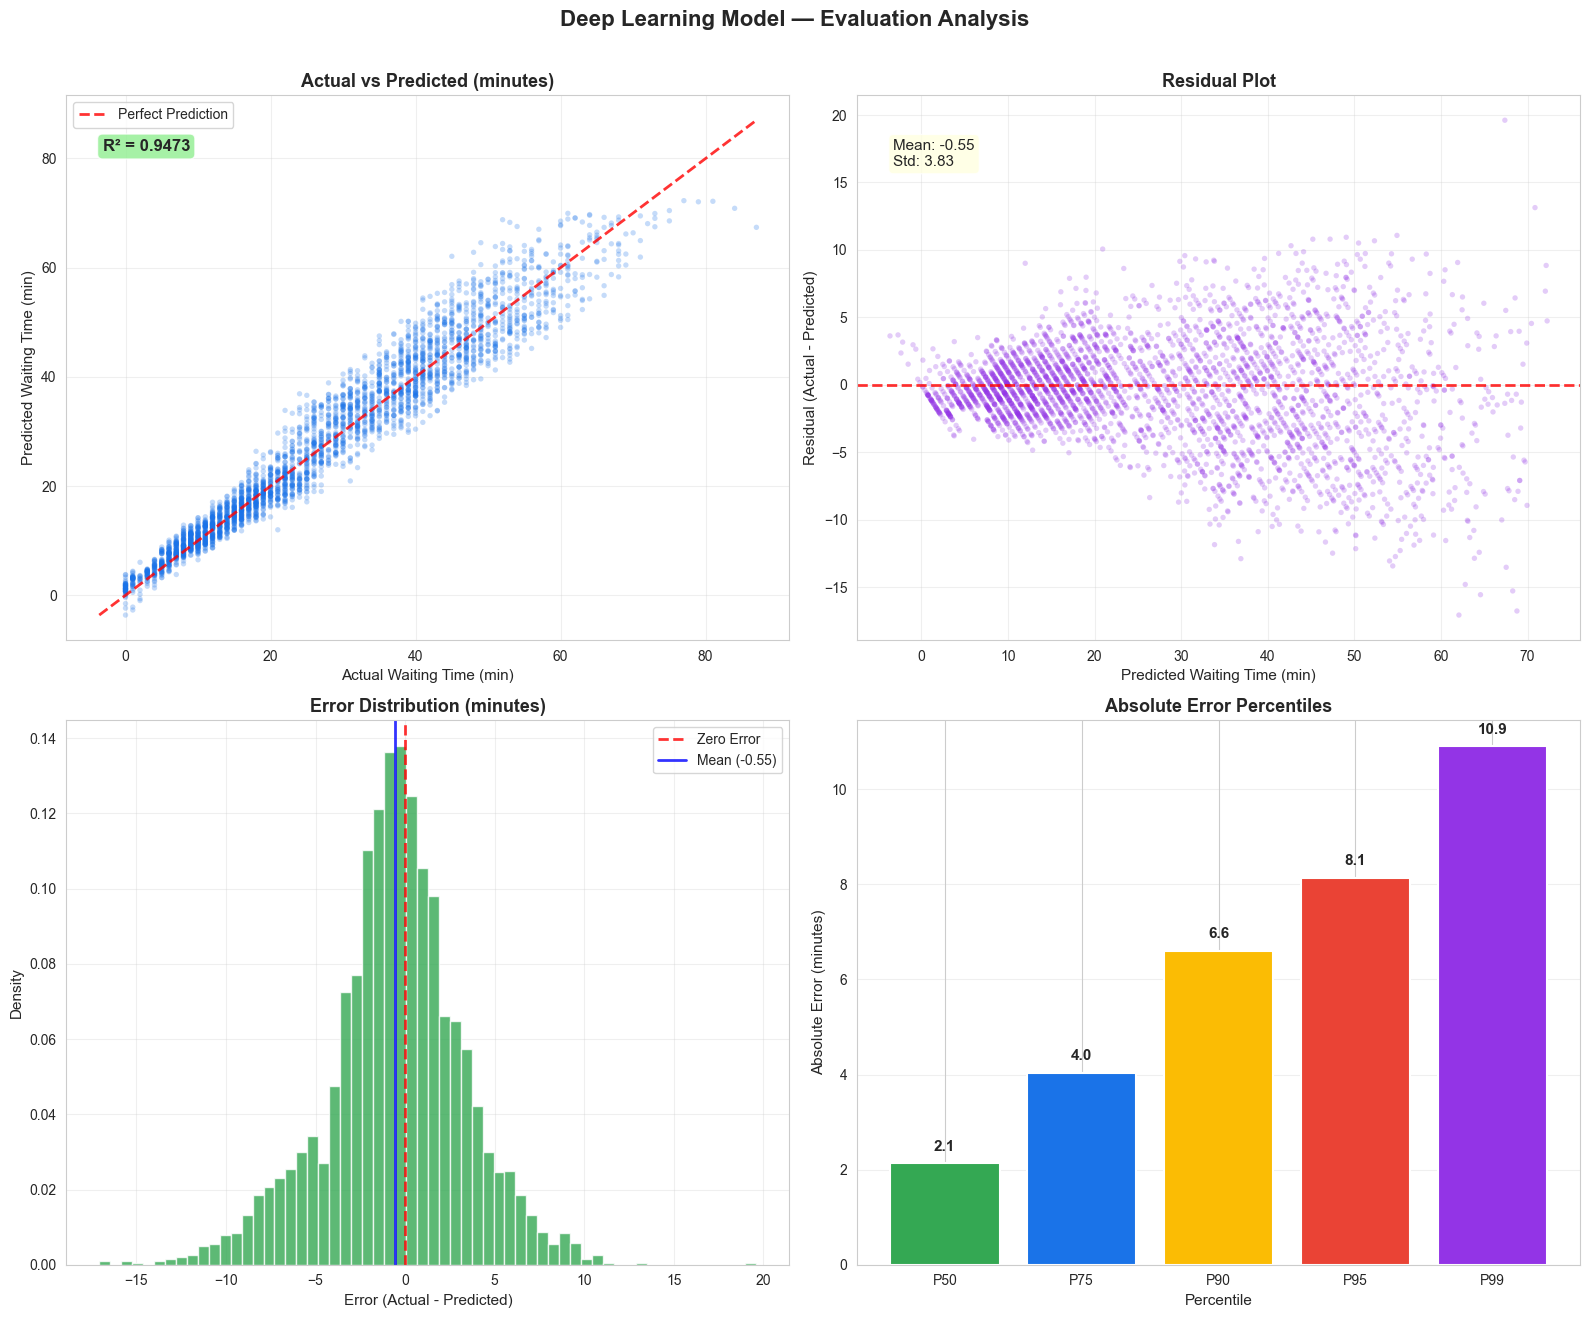


DETAILED EVALUATION METRICS
MAE:  2.90 minutes
RMSE: 3.87 minutes
R²:   0.9473 (94.73%)

Error Percentiles:
  P50: 2.14 minutes
  P75: 4.04 minutes
  P90: 6.61 minutes
  P95: 8.14 minutes
  P99: 10.90 minutes


In [17]:
# === EVALUATION VISUALIZATION ===
sns.set_style('whitegrid')

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
fig.suptitle('Deep Learning Model — Evaluation Analysis', fontsize=16, fontweight='bold', y=1.01)

residuals = y_test_actual - dl_pred_actual

# --- Plot 1: Actual vs Predicted Scatter ---
axes[0, 0].scatter(y_test_actual, dl_pred_actual, alpha=0.25, s=15, color='#1a73e8', edgecolors='none')
min_val = min(y_test_actual.min(), dl_pred_actual.min())
max_val = max(y_test_actual.max(), dl_pred_actual.max())
axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction', alpha=0.8)
axes[0, 0].set_title('Actual vs Predicted (minutes)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Actual Waiting Time (min)', fontsize=11)
axes[0, 0].set_ylabel('Predicted Waiting Time (min)', fontsize=11)
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# R² annotation
axes[0, 0].text(0.05, 0.92, f'R² = {dl_r2:.4f}', transform=axes[0, 0].transAxes,
                fontsize=12, fontweight='bold', verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

# --- Plot 2: Residual Plot ---
axes[0, 1].scatter(dl_pred_actual, residuals, alpha=0.25, s=15, color='#9334e6', edgecolors='none')
axes[0, 1].axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.8)
axes[0, 1].set_title('Residual Plot', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Predicted Waiting Time (min)', fontsize=11)
axes[0, 1].set_ylabel('Residual (Actual - Predicted)', fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# Mean and std annotations
axes[0, 1].text(0.05, 0.92, f'Mean: {residuals.mean():.2f}\nStd: {residuals.std():.2f}',
                transform=axes[0, 1].transAxes, fontsize=11, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# --- Plot 3: Error Distribution ---
axes[1, 0].hist(residuals, bins=60, color='#34a853', edgecolor='white', alpha=0.8, density=True)
axes[1, 0].axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.8, label='Zero Error')
axes[1, 0].axvline(x=residuals.mean(), color='blue', linestyle='-', linewidth=2, alpha=0.8,
                    label=f'Mean ({residuals.mean():.2f})')
axes[1, 0].set_title('Error Distribution (minutes)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Error (Actual - Predicted)', fontsize=11)
axes[1, 0].set_ylabel('Density', fontsize=11)
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# --- Plot 4: Error Percentiles ---
percentiles = [50, 75, 90, 95, 99]
abs_errors = np.abs(residuals)
pct_values = [np.percentile(abs_errors, p) for p in percentiles]
pct_colors = ['#34a853', '#1a73e8', '#fbbc04', '#ea4335', '#9334e6']
bars = axes[1, 1].bar([f'P{p}' for p in percentiles], pct_values,
                       color=pct_colors, edgecolor='white', linewidth=1.5)
axes[1, 1].set_title('Absolute Error Percentiles', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Percentile', fontsize=11)
axes[1, 1].set_ylabel('Absolute Error (minutes)', fontsize=11)
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars, pct_values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.2,
                    f'{val:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'evaluation_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print detailed metrics
print(f"\n{'='*60}")
print(f"DETAILED EVALUATION METRICS")
print(f"{'='*60}")
print(f"MAE:  {dl_mae_actual:.2f} minutes")
print(f"RMSE: {dl_rmse_actual:.2f} minutes")
print(f"R²:   {dl_r2:.4f} ({dl_r2*100:.2f}%)")
print(f"\nError Percentiles:")
for p, v in zip(percentiles, pct_values):
    print(f"  P{p}: {v:.2f} minutes")
print(f"{'='*60}")

### 6. Perbandingan Model

Untuk memvalidasi performa Deep Learning model, kita membandingkannya dengan beberapa baseline model:
- **Linear Regression** — Baseline sederhana (linear)
- **Random Forest** — Ensemble of decision trees
- **XGBoost** — Gradient boosted trees (state-of-the-art untuk tabular data)
- **LSTM** — Recurrent neural network


Training Linear Regression...

Training Random Forest...

Training XGBoost...

Training LSTM...

=== COMPARISON (REAL MINUTES) ===
            Model      MAE     RMSE       R2
Linear Regression 3.388407 4.366500 0.932950
    Random Forest 2.651816 3.595779 0.954531
          XGBoost 2.550060 3.406029 0.959203
             LSTM 2.897842 3.817211 0.948758
    Deep Learning 2.899817 3.872852 0.947253


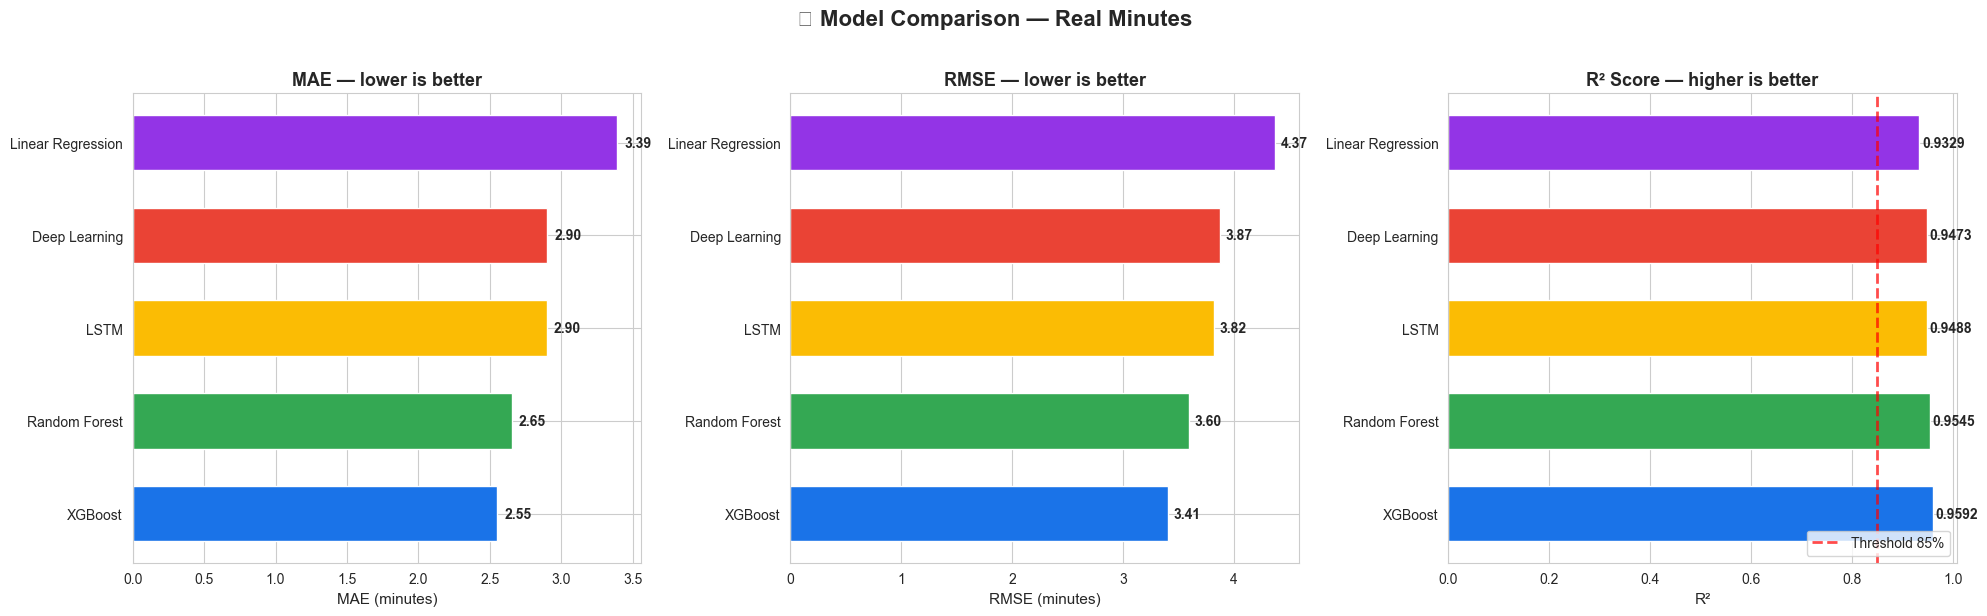


FEATURE IMPORTANCE (XGBoost)


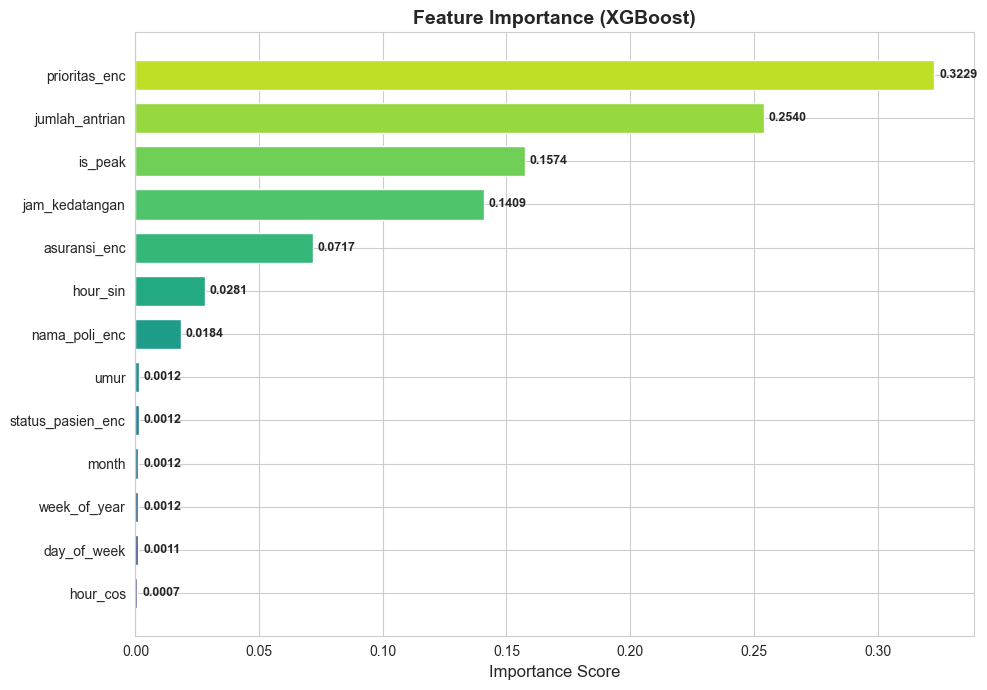


Top 5 Most Important Features:
  prioritas_enc        — 0.3229
  jumlah_antrian       — 0.2540
  is_peak              — 0.1574
  jam_kedatangan       — 0.1409
  asuransi_enc         — 0.0717


In [18]:
print("\nTraining Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_pred_actual = target_scaler.inverse_transform(lr_pred.reshape(-1, 1)).flatten()
lr_mae_actual = mean_absolute_error(y_test_actual, lr_pred_actual)
lr_rmse_actual = np.sqrt(mean_squared_error(y_test_actual, lr_pred_actual))
lr_r2 = r2_score(y_test_actual, lr_pred_actual)

print("\nTraining Random Forest...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_pred_actual = target_scaler.inverse_transform(rf_pred.reshape(-1, 1)).flatten()
rf_mae_actual = mean_absolute_error(y_test_actual, rf_pred_actual)
rf_rmse_actual = np.sqrt(mean_squared_error(y_test_actual, rf_pred_actual))
rf_r2 = r2_score(y_test_actual, rf_pred_actual)

print("\nTraining XGBoost...")
xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_pred_actual = target_scaler.inverse_transform(xgb_pred.reshape(-1, 1)).flatten()
xgb_mae_actual = mean_absolute_error(y_test_actual, xgb_pred_actual)
xgb_rmse_actual = np.sqrt(mean_squared_error(y_test_actual, xgb_pred_actual))
xgb_r2 = r2_score(y_test_actual, xgb_pred_actual)

print("\nTraining LSTM...")
X_train_lstm = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))
lstm_model = Sequential([
    LSTM(64, activation='relu', input_shape=(1, X_train.shape[1])),
    Dense(32, activation='relu'),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm_model.fit(X_train_lstm, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=0)
lstm_pred = lstm_model.predict(X_test_lstm, verbose=0)
lstm_pred_actual = target_scaler.inverse_transform(lstm_pred.reshape(-1, 1)).flatten()
lstm_mae_actual = mean_absolute_error(y_test_actual, lstm_pred_actual)
lstm_rmse_actual = np.sqrt(mean_squared_error(y_test_actual, lstm_pred_actual))
lstm_r2 = r2_score(y_test_actual, lstm_pred_actual)

print("\n=== COMPARISON (REAL MINUTES) ===")
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost', 'LSTM', 'Deep Learning'],
    'MAE': [lr_mae_actual, rf_mae_actual, xgb_mae_actual, lstm_mae_actual, dl_mae_actual],
    'RMSE': [lr_rmse_actual, rf_rmse_actual, xgb_rmse_actual, lstm_rmse_actual, dl_rmse_actual],
    'R2': [lr_r2, rf_r2, xgb_r2, lstm_r2, dl_r2]
})
print(comparison_df.to_string(index=False))

# === VISUALIZATION: MODEL COMPARISON BAR CHARTS ===
sns.set_style('whitegrid')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('📊 Model Comparison — Real Minutes', fontsize=16, fontweight='bold', y=1.02)

model_colors = ['#1a73e8', '#34a853', '#fbbc04', '#ea4335', '#9334e6']
comparison_sorted_mae = comparison_df.sort_values('MAE', ascending=True)
comparison_sorted_rmse = comparison_df.sort_values('RMSE', ascending=True)
comparison_sorted_r2 = comparison_df.sort_values('R2', ascending=False)

# Bar 1: MAE
bars1 = axes[0].barh(comparison_sorted_mae['Model'], comparison_sorted_mae['MAE'],
                      color=model_colors, edgecolor='white', height=0.6)
axes[0].set_title('MAE — lower is better', fontsize=13, fontweight='bold')
axes[0].set_xlabel('MAE (minutes)', fontsize=11)
for bar, val in zip(bars1, comparison_sorted_mae['MAE']):
    axes[0].text(val + 0.05, bar.get_y() + bar.get_height()/2., f'{val:.2f}',
                 va='center', fontweight='bold', fontsize=10)

# Bar 2: RMSE
bars2 = axes[1].barh(comparison_sorted_rmse['Model'], comparison_sorted_rmse['RMSE'],
                      color=model_colors, edgecolor='white', height=0.6)
axes[1].set_title('RMSE — lower is better', fontsize=13, fontweight='bold')
axes[1].set_xlabel('RMSE (minutes)', fontsize=11)
for bar, val in zip(bars2, comparison_sorted_rmse['RMSE']):
    axes[1].text(val + 0.05, bar.get_y() + bar.get_height()/2., f'{val:.2f}',
                 va='center', fontweight='bold', fontsize=10)

# Bar 3: R²
bars3 = axes[2].barh(comparison_sorted_r2['Model'], comparison_sorted_r2['R2'],
                      color=model_colors, edgecolor='white', height=0.6)
axes[2].set_title('R² Score — higher is better', fontsize=13, fontweight='bold')
axes[2].set_xlabel('R²', fontsize=11)
axes[2].axvline(x=0.85, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Threshold 85%')
axes[2].legend(fontsize=10, loc='lower right')
for bar, val in zip(bars3, comparison_sorted_r2['R2']):
    axes[2].text(val + 0.005, bar.get_y() + bar.get_height()/2., f'{val:.4f}',
                 va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

# === FEATURE IMPORTANCE (XGBoost) ===
print("\n" + "="*60)
print("FEATURE IMPORTANCE (XGBoost)")
print("="*60)

xgb_importances = xgb_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': xgb_importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(importance_df['Feature'], importance_df['Importance'],
               color=plt.cm.viridis(np.linspace(0.2, 0.9, len(importance_df))),
               edgecolor='white', height=0.7)
ax.set_title('Feature Importance (XGBoost)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=12)

# Add value labels
for bar, val in zip(bars, importance_df['Importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2., f'{val:.4f}',
            va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print top features
print("\nTop 5 Most Important Features:")
for _, row in importance_df.tail(5).iloc[::-1].iterrows():
    print(f"  {row['Feature']:20s} — {row['Importance']:.4f}")

### 7. Inference Test

Demonstrasi penggunaan model untuk melakukan prediksi pada data baru. Test ini mensimulasikan request yang akan diterima oleh REST API (`app/app.py`):

In [19]:
print("\n=== INFERENCE TEST ===")
test_features = {
    'umur': 35,
    'jumlah_antrian': 10,
    'jam_kedatangan': 13,
    'asuransi_enc': 1,
    'prioritas_enc': 0, # Fixed from 2
    'status_pasien_enc': 0,
    'nama_poli_enc': 3,
}
test_date = pd.to_datetime('2025-04-15')

test_features['is_peak'] = int(8 <= test_features['jam_kedatangan'] <= 11)
test_features['day_of_week'] = test_date.dayofweek
test_features['month'] = test_date.month
test_features['week_of_year'] = test_date.isocalendar().week
test_features['hour_sin'] = np.sin(2 * np.pi * test_features['jam_kedatangan'] / 24)
test_features['hour_cos'] = np.cos(2 * np.pi * test_features['jam_kedatangan'] / 24)

sample_data = pd.DataFrame([test_features]).reindex(columns=feature_columns)
sample_scaled = scaler.transform(sample_data)

pred_scaled = model.predict(sample_scaled, verbose=0)
pred_actual = target_scaler.inverse_transform(pred_scaled.reshape(-1, 1))[0][0]

print(f"Sample Features: {test_features}")
print(f"Predicted Waiting Time: {pred_actual:.2f} minutes")
print("\nDone. All artifacts saved in deployment/model/")


=== INFERENCE TEST ===
Sample Features: {'umur': 35, 'jumlah_antrian': 10, 'jam_kedatangan': 13, 'asuransi_enc': 1, 'prioritas_enc': 0, 'status_pasien_enc': 0, 'nama_poli_enc': 3, 'is_peak': 0, 'day_of_week': 1, 'month': 4, 'week_of_year': 16, 'hour_sin': np.float64(-0.2588190451025208), 'hour_cos': np.float64(-0.9659258262890683)}
Predicted Waiting Time: 16.85 minutes

Done. All artifacts saved in deployment/model/


---

## ✅ Kesimpulan

### Komponen Custom yang Telah Diimplementasikan:

| # | Komponen | Class / Metode | Status |
|---|----------|---------------|--------|
| 1 | Custom Model (Functional API) | `Model(inputs, outputs)` + `ResidualDenseBlock` | ✅ |
| 2 | Custom Layer | `ResidualDenseBlock` (Dense + BN + Residual) | ✅ |
| 3 | Custom Loss Function | `WeightedHuberLoss` (asymmetric Huber) | ✅ |
| 4 | Custom Callback | `DetailedTrainingLogger` (JSON logging) | ✅ |
| 5 | Custom Training Loop | `tf.GradientTape` demonstration | ✅ |
| 6 | TensorBoard Integration | Logging + inline visualization | ✅ |
| 7 | Model Export | `best_model.keras` via `ModelCheckpoint` | ✅ |
| 8 | REST API | FastAPI (`app/app.py`) | ✅ |
| 9 | Inference Test | Simulasi prediksi data baru | ✅ |
